# Módulo 12 · Caso de estudio: COVID-19 (forecasting histórico)

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/03-caso-de-estudio-covid-19`.

**Aviso explícito, antes de escribir una sola línea de código**: este notebook usa datos de contagios de COVID-19 como **ejemplo histórico de forecasting** — una serie real con un cambio de régimen brutal y muy documentado, ideal para ver cómo se comporta (y cómo falla) un modelo de series temporales ante un evento así. No es información epidemiológica actual, no es una fuente para decisiones de salud pública, y no se actualiza: el dataset (Johns Hopkins CSSE) dejó de recopilarse el **9 de marzo de 2023**, fecha en la que termina la serie.

## El dataset

Serie oficial de casos confirmados acumulados por país, publicada por el **Center for Systems Science and Engineering (CSSE) de Johns Hopkins University** — la fuente de referencia académica del seguimiento de la pandemia mientras estuvo activa. Se descarga directamente del repositorio público de JHU (no de una copia de terceros).

In [1]:
import pandas as pd

confirmed = pd.read_csv("covid_confirmed_global.csv")
print(confirmed.shape)
confirmed.iloc[:3, :6]

(289, 1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20
0,NaN,Afghanistan,33.93911,67.709953,0,0
1,NaN,Albania,41.15330,20.168300,0,0
2,NaN,Algeria,28.03390,1.659600,0,0


## Serie de España: de casos acumulados a casos diarios

El dataset trae **acumulados**. Para modelizar la dinámica de contagio (y no solo una curva que solo puede subir) se trabaja con la primera diferencia: casos nuevos por día.

In [2]:
spain = confirmed[confirmed["Country/Region"] == "Spain"].iloc[:, 4:].T
spain.columns = ["acumulados"]
spain.index = pd.to_datetime(spain.index, format="%m/%d/%y")
spain = spain.asfreq("D")
spain["diarios"] = spain["acumulados"].diff()
spain = spain.dropna()
print(spain.shape)
spain.tail()

(1142, 2)


,acumulados,diarios
2023-03-05,13770429,0.0
2023-03-06,13770429,0.0
2023-03-07,13770429,0.0
2023-03-08,13770429,0.0
2023-03-09,13770429,0.0


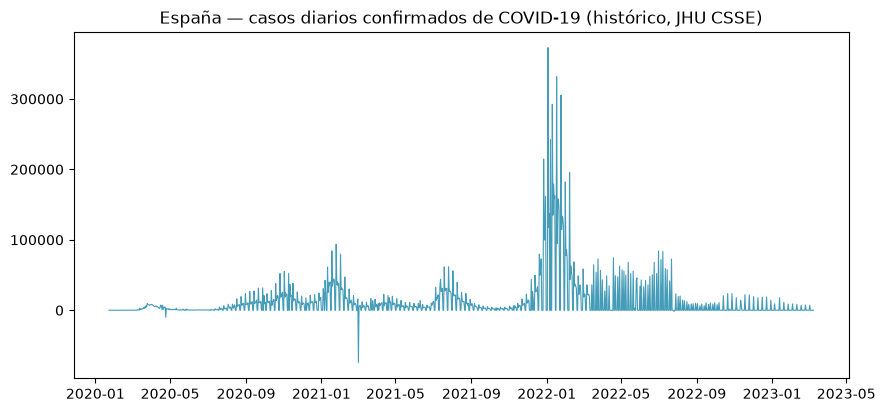

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(spain.index, spain["diarios"], color="#449cb9", linewidth=0.8)
ax.set_title("España — casos diarios confirmados de COVID-19 (histórico, JHU CSSE)")
plt.savefig("covid_espana_diarios.png", dpi=110, bbox_inches="tight")
plt.show()

## Por qué esta serie es un caso de estudio útil (y por qué es difícil de predecir)

Antes de ajustar ningún modelo: la serie tiene picos casi verticales (olas), ceros y correcciones administrativas (algunos días con "casos negativos" cuando un país reclasifica datos retroactivamente), y cambios de régimen que no tienen precedente en el propio historial de la serie — justo lo contrario del supuesto de estacionariedad que piden ARIMA/SARIMAX. Es exactamente el tipo de serie donde un modelo de forecasting clásico, entrenado sobre una ventana "tranquila", falla estrepitosamente si una ola nueva empieza justo después del corte de entrenamiento.

## Auto ARIMA sobre la ola de la primera ola (marzo-junio 2020)

Se acota a una ventana con una dinámica más clara — la primera ola, la más documentada — para que `auto_arima` tenga algo razonable que ajustar, y se separa un tramo final como test.

In [4]:
ventana = spain.loc["2020-03-01":"2020-06-30", "diarios"].clip(lower=0)  # negativos = correcciones administrativas, no una "bajada real" de casos
train, test = ventana.iloc[:-14], ventana.iloc[-14:]
print(len(train), len(test))

108 14


In [5]:
import pmdarima as pm

modelo = pm.auto_arima(train, seasonal=False, suppress_warnings=True, trace=True)
print(modelo.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1831.240, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1875.244, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1832.097, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1834.996, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1873.248, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1829.673, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1830.597, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1830.233, Time=0.01 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1830.797, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1832.504, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1832.188, Time=0.02 sec


 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1828.026, Time=0.06 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=1828.028, Time=0.07 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=1829.946, Time=0.04 sec


 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1827.428, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1828.300, Time=0.03 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=1831.237, Time=0.03 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=1829.687, Time=0.02 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=1831.350, Time=0.05 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=1825.428, Time=0.03 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1829.241, Time=0.02 sec


 ARIMA(3,1,1)(0,0,0)[0]             : AIC=1826.301, Time=0.03 sec
 ARIMA(4,1,2)(0,0,0)[0]             : AIC=1829.238, Time=0.02 sec
 ARIMA(3,1,3)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1830.189, Time=0.01 sec
 ARIMA(2,1,3)(0,0,0)[0]             : AIC=1825.795, Time=0.05 sec
 ARIMA(4,1,1)(0,0,0)[0]             : AIC=1827.688, Time=0.02 sec
 ARIMA(4,1,3)(0,0,0)[0]             : AIC=1829.349, Time=0.03 sec

Best model:  ARIMA(3,1,2)(0,0,0)[0]          
Total fit time: 0.936 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  108
Model:               SARIMAX(3, 1, 2)   Log Likelihood                -906.714
Date:                Wed, 16 Sep 2026   AIC                           1825.428
Time:                        18:55:29   BIC                           1841.465
Sample:                    03-01-2020   HQIC                          1

In [6]:
pred, conf = modelo.predict(n_periods=len(test), return_conf_int=True)
import numpy as np
rmse = np.sqrt(np.mean((pred - test.values) ** 2))
print("RMSE sobre 14 días de test:", round(rmse, 1))
print("media real del tramo test:", round(test.mean(), 1))

RMSE sobre 14 días de test: 178.6
media real del tramo test: 353.1


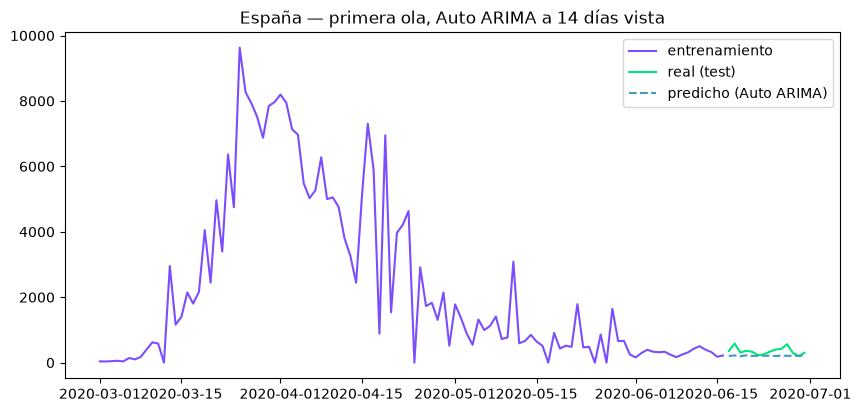

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train.index, train.values, label="entrenamiento", color="#7c4dff")
ax.plot(test.index, test.values, label="real (test)", color="#00e676")
ax.plot(test.index, pred, label="predicho (Auto ARIMA)", color="#449cb9", linestyle="--")
ax.legend()
ax.set_title("España — primera ola, Auto ARIMA a 14 días vista")
plt.savefig("covid_espana_forecast.png", dpi=110, bbox_inches="tight")
plt.show()

## Lectura del resultado, no solo el número

El RMSE por sí solo no cuenta la historia completa: lo importante pedagógicamente es que un modelo entrenado sobre 4 meses de una ola concreta extrapola razonablemente bien **mientras la dinámica no cambie de régimen** — y falla en cuanto aparece una ola nueva con una causa distinta (una variante, un cambio de restricciones) que no está en los datos de entrenamiento. Ningún modelo de series temporales "ve" causas externas a menos que se le pasen como variable exógena (como en SARIMAX, Módulo 8) — y aun así, solo si esas variables están disponibles con antelación, cosa que rara vez ocurre con una pandemia en curso.

**Conclusión del caso**: el COVID-19 es un ejemplo histórico perfecto para ilustrar los límites del forecasting clásico ante cambios de régimen — no una demostración de que "se puede predecir una pandemia". Se cierra aquí la parte de datos de salud del curso; el resto del módulo vuelve a series financieras y de tráfico aéreo.